### Healthcare Insurance Claim Fraud Detection — Exploratory Data Analysis

## Objective

The objective of this EDA is to understand the structure, quality,
distribution, relationships, and fraud-related patterns in the
healthcare insurance claims data.

### Datasets

1. Provider / Fraud Label Dataset
2. Beneficiary Dataset
3. Inpatient Claims Dataset
4. Outpatient Claims Dataset

### Key Question

What characteristics and claim patterns distinguish potentially
fraudulent healthcare providers from non-fraudulent providers?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
beneficiary_df = pd.read_csv("../data/raw/train/BENEFICIARY.csv")

inpatient_df = pd.read_csv("../data/raw/train/INPATIENT.csv")

outpatient_df = pd.read_csv("../data/raw/train/OUTPATIENT.csv")

provider_df = pd.read_csv("../data/raw/train/PROVIDERS.csv")

In [3]:
print("SHAPES")
print("Beneficiary:", beneficiary_df.shape)
print("Inpatient:", inpatient_df.shape)
print("Outpatient:", outpatient_df.shape)   
print("Provider:", provider_df.shape)

SHAPES
Beneficiary: (138556, 25)
Inpatient: (40474, 30)
Outpatient: (517737, 27)
Provider: (5410, 2)


In [4]:

beneficiary_df.columns.tolist()

['BeneID',
 'DOB',
 'DOD',
 'Gender',
 'Race',
 'RenalDiseaseIndicator',
 'State',
 'County',
 'NoOfMonths_PartACov',
 'NoOfMonths_PartBCov',
 'ChronicCond_Alzheimer',
 'ChronicCond_Heartfailure',
 'ChronicCond_KidneyDisease',
 'ChronicCond_Cancer',
 'ChronicCond_ObstrPulmonary',
 'ChronicCond_Depression',
 'ChronicCond_Diabetes',
 'ChronicCond_IschemicHeart',
 'ChronicCond_Osteoporasis',
 'ChronicCond_rheumatoidarthritis',
 'ChronicCond_stroke',
 'IPAnnualReimbursementAmt',
 'IPAnnualDeductibleAmt',
 'OPAnnualReimbursementAmt',
 'OPAnnualDeductibleAmt']

In [5]:
print("\nadmitted in hospital:")
inpatient_df.columns.tolist()


admitted in hospital:


['BeneID',
 'ClaimID',
 'ClaimStartDt',
 'ClaimEndDt',
 'Provider',
 'InscClaimAmtReimbursed',
 'AttendingPhysician',
 'OperatingPhysician',
 'OtherPhysician',
 'AdmissionDt',
 'ClmAdmitDiagnosisCode',
 'DeductibleAmtPaid',
 'DischargeDt',
 'DiagnosisGroupCode',
 'ClmDiagnosisCode_1',
 'ClmDiagnosisCode_2',
 'ClmDiagnosisCode_3',
 'ClmDiagnosisCode_4',
 'ClmDiagnosisCode_5',
 'ClmDiagnosisCode_6',
 'ClmDiagnosisCode_7',
 'ClmDiagnosisCode_8',
 'ClmDiagnosisCode_9',
 'ClmDiagnosisCode_10',
 'ClmProcedureCode_1',
 'ClmProcedureCode_2',
 'ClmProcedureCode_3',
 'ClmProcedureCode_4',
 'ClmProcedureCode_5',
 'ClmProcedureCode_6']

In [6]:
print("visits to hospital:")
outpatient_df.columns.tolist()

visits to hospital:


['BeneID',
 'ClaimID',
 'ClaimStartDt',
 'ClaimEndDt',
 'Provider',
 'InscClaimAmtReimbursed',
 'AttendingPhysician',
 'OperatingPhysician',
 'OtherPhysician',
 'ClmDiagnosisCode_1',
 'ClmDiagnosisCode_2',
 'ClmDiagnosisCode_3',
 'ClmDiagnosisCode_4',
 'ClmDiagnosisCode_5',
 'ClmDiagnosisCode_6',
 'ClmDiagnosisCode_7',
 'ClmDiagnosisCode_8',
 'ClmDiagnosisCode_9',
 'ClmDiagnosisCode_10',
 'ClmProcedureCode_1',
 'ClmProcedureCode_2',
 'ClmProcedureCode_3',
 'ClmProcedureCode_4',
 'ClmProcedureCode_5',
 'ClmProcedureCode_6',
 'DeductibleAmtPaid',
 'ClmAdmitDiagnosisCode']

In [7]:
print("provider data:")
provider_df.columns.tolist()

provider data:


['Provider', 'PotentialFraud']

In [8]:
provider_df.head()

,Provider,PotentialFraud
0,PRV51001,No
1,PRV51003,Yes
2,PRV51004,No
3,PRV51005,Yes
4,PRV51007,No


In [9]:
beneficiary_df.head(2)

,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,...,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,...,1,1,1,2,1,1,36000,3204,60,70
1,BENE11002,1936-09-01,NaN,2,1,0,39,280,12,12,...,2,2,2,2,2,2,0,0,30,50


In [10]:
inpatient_df.head(2)

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,...,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,...,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN


In [11]:
outpatient_df.head(2)

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,...,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DeductibleAmtPaid,ClmAdmitDiagnosisCode
0,BENE11002,CLM624349,2009-10-11,2009-10-11,PRV56011,30,PHY326117,NaN,NaN,78943,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,56409
1,BENE11003,CLM189947,2009-02-12,2009-02-12,PRV57610,80,PHY362868,NaN,NaN,6115,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,79380


# How are these four datasets connected?

In [12]:
#PROVIDER ID CONNECTS ALL DATASETS PROVIDER ID ->INPATIENT/OUTPATIENT -> BENEFICIARY

print("Provider ID connects all datasets: Provider ID -> Inpatient/Outpatient -> Beneficiary")

print(provider_df['Provider'].head())
print(inpatient_df['Provider'].head())
print(outpatient_df['Provider'].head())


Provider ID connects all datasets: Provider ID -> Inpatient/Outpatient -> Beneficiary
0    PRV51001
1    PRV51003
2    PRV51004
3    PRV51005
4    PRV51007
Name: Provider, dtype: str
0    PRV55912
1    PRV55907
2    PRV56046
3    PRV52405
4    PRV56614
Name: Provider, dtype: str
0    PRV56011
1    PRV57610
2    PRV57595
3    PRV56011
4    PRV56011
Name: Provider, dtype: str


In [13]:
print("bene ID connects inpatient and outpatient datasets: Bene ID -> Inpatient/Outpatient")

print(inpatient_df['BeneID'].head())
print(outpatient_df['BeneID'].head())
print(beneficiary_df['BeneID'].head())

bene ID connects inpatient and outpatient datasets: Bene ID -> Inpatient/Outpatient
0    BENE11001
1    BENE11001
2    BENE11001
3    BENE11011
4    BENE11014
Name: BeneID, dtype: str
0    BENE11002
1    BENE11003
2    BENE11003
3    BENE11004
4    BENE11004
Name: BeneID, dtype: str
0    BENE11001
1    BENE11002
2    BENE11003
3    BENE11004
4    BENE11005
Name: BeneID, dtype: str



#checking how many unique IDs exist

In [14]:
print("unique providers\n")

print("Provider:", provider_df['Provider'].nunique())
print("Inpatient:", inpatient_df['Provider'].nunique())
print("Outpatient:",outpatient_df['Provider'].nunique())

unique providers

Provider: 5410
Inpatient: 2092
Outpatient: 5012


In [15]:
print("unique bene IDs in inpatient and outpatient datasets:")
print("Inpatient:", inpatient_df['BeneID'].nunique())
print("Outpatient:", outpatient_df['BeneID'].nunique()) 
print("Beneficiary:", beneficiary_df['BeneID'].nunique())

unique bene IDs in inpatient and outpatient datasets:
Inpatient: 31289
Outpatient: 133980
Beneficiary: 138556


In [16]:
datasets = {
    "Provider": provider_df,
    "Beneficiary": beneficiary_df,
    "Inpatient": inpatient_df,
    "Outpatient": outpatient_df
}

In [17]:
for name, df in datasets.items():
    print(f"\n{name} data types:")
    display(df.dtypes.to_frame("dtype"))


Provider data types:


,dtype
Provider,str
PotentialFraud,str



Beneficiary data types:


,dtype
BeneID,str
DOB,str
DOD,str
Gender,int64
Race,int64
RenalDiseaseIndicator,str
State,int64
County,int64
NoOfMonths_PartACov,int64
NoOfMonths_PartBCov,int64



Inpatient data types:


,dtype
BeneID,str
ClaimID,str
ClaimStartDt,str
ClaimEndDt,str
Provider,str
InscClaimAmtReimbursed,int64
AttendingPhysician,str
OperatingPhysician,str
OtherPhysician,str
AdmissionDt,str



Outpatient data types:


,dtype
BeneID,str
ClaimID,str
ClaimStartDt,str
ClaimEndDt,str
Provider,str
InscClaimAmtReimbursed,int64
AttendingPhysician,str
OperatingPhysician,str
OtherPhysician,str
ClmDiagnosisCode_1,str


In [18]:
for name, df in datasets.items():
    duplicate_count = df.duplicated().sum()

    print(
        f"{name}: {duplicate_count:,} duplicate rows "
        f"({duplicate_count / len(df) * 100:.2f}%)"
    )

Provider: 0 duplicate rows (0.00%)
Beneficiary: 0 duplicate rows (0.00%)
Inpatient: 0 duplicate rows (0.00%)
Outpatient: 0 duplicate rows (0.00%)


In [19]:
def missing_summary(df):
    result = pd.DataFrame({
        "Missing_Count": df.isna().sum(),
        "Missing_Percentage": df.isna().mean() * 100
    })

    return result.sort_values(
        "Missing_Percentage",
        ascending=False
    )

for name, df in datasets.items():
    print(f"\n{name}")
    display(missing_summary(df).head(20))


Provider


,Missing_Count,Missing_Percentage
Provider,0,0.0
PotentialFraud,0,0.0



Beneficiary


,Missing_Count,Missing_Percentage
DOD,137135,98.974422
BeneID,0,0.000000
DOB,0,0.000000
Gender,0,0.000000
Race,0,0.000000
RenalDiseaseIndicator,0,0.000000
State,0,0.000000
County,0,0.000000
NoOfMonths_PartACov,0,0.000000
NoOfMonths_PartBCov,0,0.000000



Inpatient


,Missing_Count,Missing_Percentage
ClmProcedureCode_6,40474,100.000000
ClmProcedureCode_5,40465,99.977764
ClmProcedureCode_4,40358,99.713396
ClmProcedureCode_3,39509,97.615753
ClmDiagnosisCode_10,36547,90.297475
OtherPhysician,35784,88.412314
ClmProcedureCode_2,35020,86.524683
ClmProcedureCode_1,17326,42.807728
OperatingPhysician,16644,41.122696
ClmDiagnosisCode_9,13497,33.347334



Outpatient


,Missing_Count,Missing_Percentage
ClmProcedureCode_5,517737,100.000000
ClmProcedureCode_6,517737,100.000000
ClmProcedureCode_4,517735,99.999614
ClmProcedureCode_3,517733,99.999227
ClmProcedureCode_2,517701,99.993047
ClmProcedureCode_1,517575,99.968710
ClmDiagnosisCode_10,516654,99.790820
ClmDiagnosisCode_9,502899,97.134066
ClmDiagnosisCode_8,494825,95.574587
ClmDiagnosisCode_7,484776,93.633640


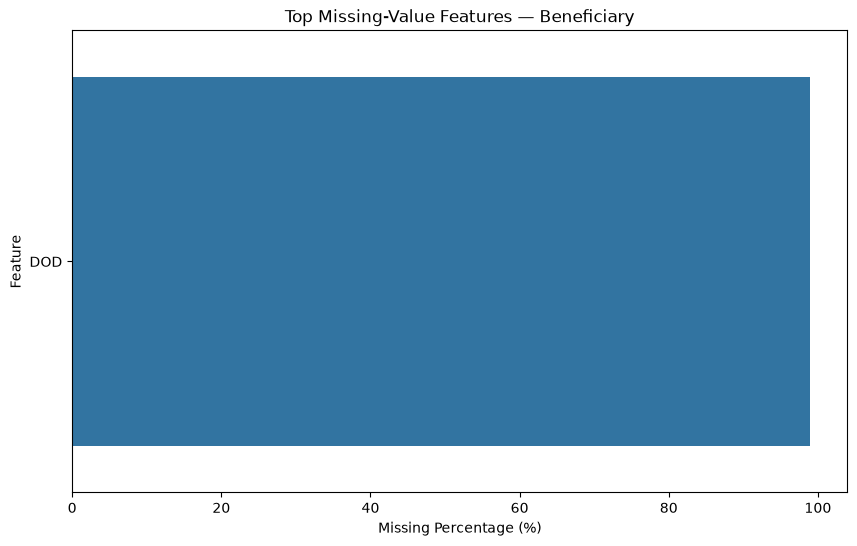

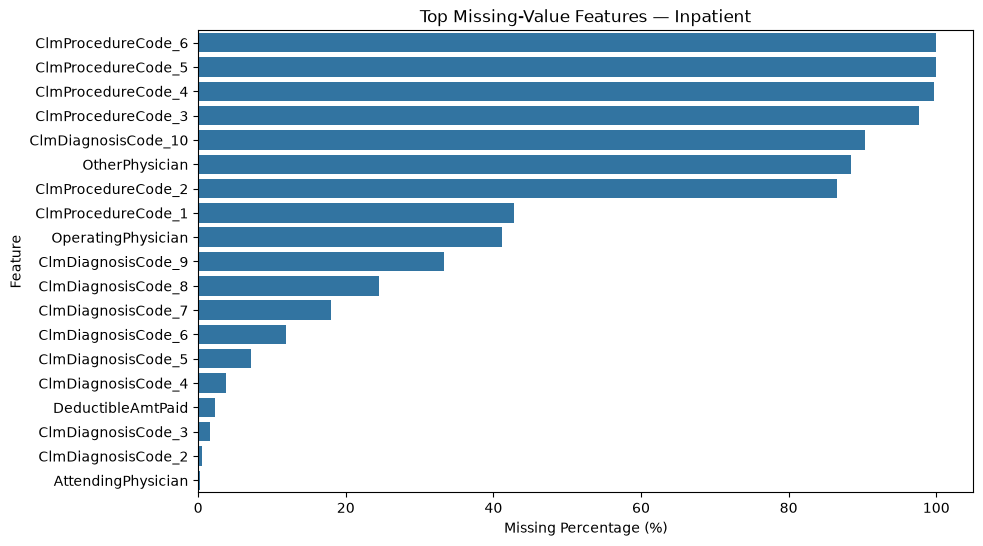

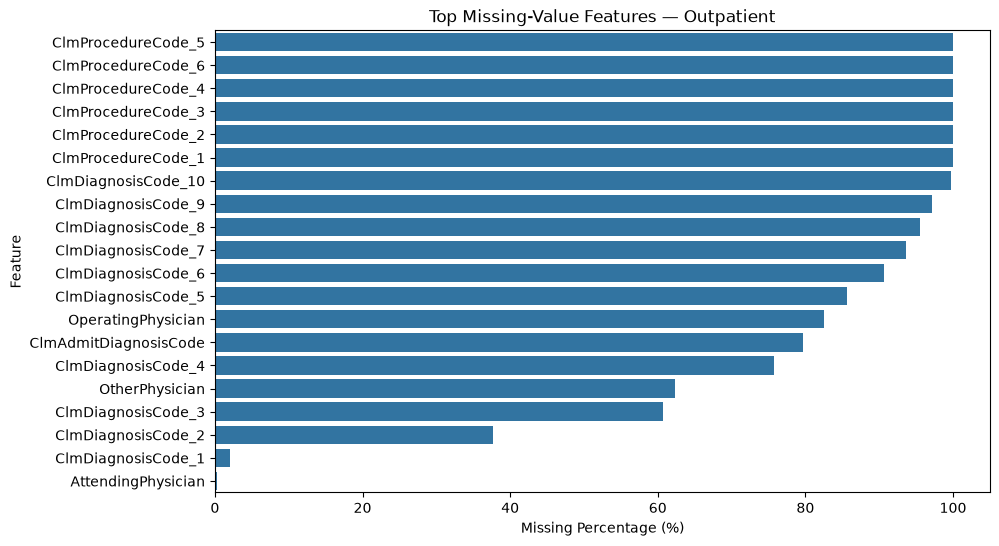

In [20]:
for name, df in datasets.items():

    missing = (
        df.isna().mean() * 100
    ).sort_values(ascending=False)

    missing = missing[missing > 0].head(20)

    if len(missing) == 0:
        continue

    plt.figure(figsize=(10, 6))
    sns.barplot(
        x=missing.values,
        y=missing.index
    )

    plt.title(f"Top Missing-Value Features — {name}")
    plt.xlabel("Missing Percentage (%)")
    plt.ylabel("Feature")
    plt.show()

In [21]:
provider_df["PotentialFraud"].value_counts()

PotentialFraud
No     4904
Yes     506
Name: count, dtype: int64

In [22]:
provider_df["PotentialFraud"].value_counts(normalize=True) * 100

PotentialFraud
No     90.64695
Yes     9.35305
Name: proportion, dtype: float64

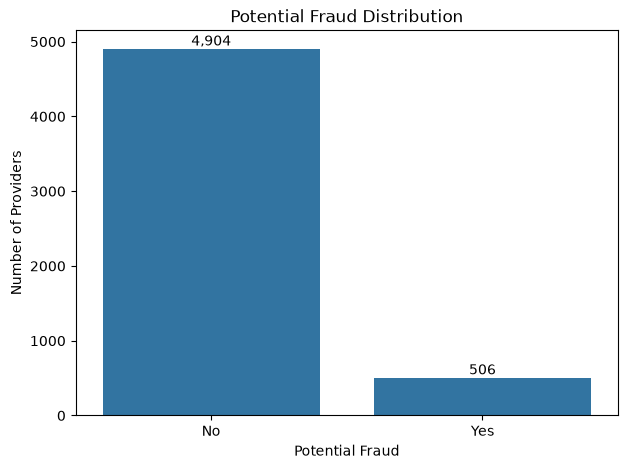

In [23]:
fraud_counts = provider_df["PotentialFraud"].value_counts()

plt.figure(figsize=(7, 5))

sns.barplot(
    x=fraud_counts.index,
    y=fraud_counts.values
)

plt.title("Potential Fraud Distribution")
plt.xlabel("Potential Fraud")
plt.ylabel("Number of Providers")

for i, value in enumerate(fraud_counts.values):
    plt.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.show()

In [24]:
fraud_distribution = (
    provider_df["PotentialFraud"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("Percentage")
    .to_frame()
)

fraud_distribution

,Percentage
PotentialFraud,
No,90.65
Yes,9.35


In [25]:
print("Total provider records:", len(provider_df))
print("Unique providers:", provider_df["Provider"].nunique())
print("Duplicate provider IDs:", provider_df["Provider"].duplicated().sum())

Total provider records: 5410
Unique providers: 5410
Duplicate provider IDs: 0


In [26]:
beneficiary_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
BeneID,138556,138556,BENE11001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DOB,138556,900,1939-10-01,540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DOD,1421,11,2009-12-01,182,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,138556.0,NaN,NaN,NaN,1.570932,0.494945,1.0,1.0,2.0,2.0,2.0
Race,138556.0,NaN,NaN,NaN,1.254511,0.717007,1.0,1.0,1.0,1.0,5.0
RenalDiseaseIndicator,138556,2,0,118978,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,138556.0,NaN,NaN,NaN,25.666734,15.223443,1.0,11.0,25.0,39.0,54.0
County,138556.0,NaN,NaN,NaN,374.424745,266.277581,0.0,141.0,340.0,570.0,999.0
NoOfMonths_PartACov,138556.0,NaN,NaN,NaN,11.907727,1.032332,0.0,12.0,12.0,12.0,12.0
NoOfMonths_PartBCov,138556.0,NaN,NaN,NaN,11.910145,0.936893,0.0,12.0,12.0,12.0,12.0


In [27]:
beneficiary_df["Gender"].value_counts(dropna=False)

Gender
2    79106
1    59450
Name: count, dtype: int64

In [28]:
beneficiary_df["Race"].value_counts(dropna=False)

Race
1    117057
2     13538
3      5059
5      2902
Name: count, dtype: int64

In [29]:
beneficiary_df["State"].value_counts(dropna=False).head(20)

State
5     12052
10     9771
45     8780
33     8443
39     6055
14     5923
36     5366
23     5293
34     4629
31     4124
11     3892
49     3623
44     3390
22     3306
15     3272
26     3108
50     2793
52     2662
1      2615
21     2570
Name: count, dtype: int64

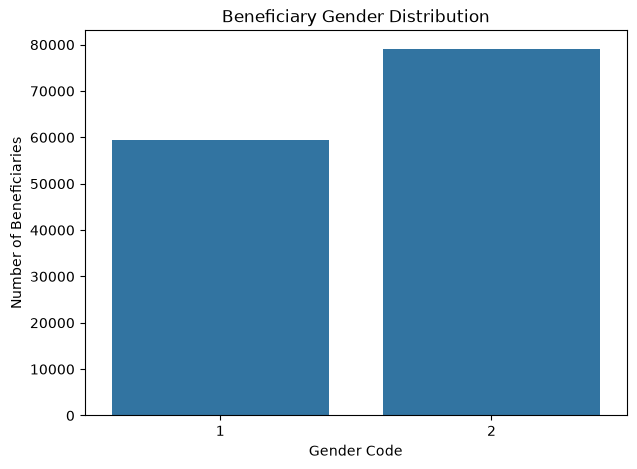

In [30]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=beneficiary_df,
    x="Gender"
)

plt.title("Beneficiary Gender Distribution")
plt.xlabel("Gender Code")
plt.ylabel("Number of Beneficiaries")

plt.show()

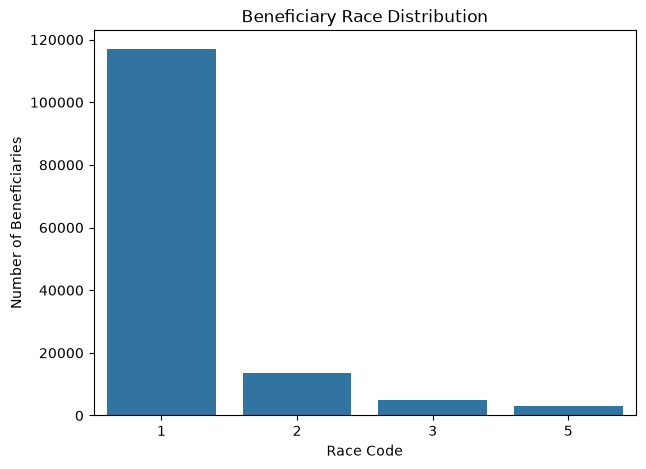

In [31]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=beneficiary_df,
    x="Race"
)

plt.title("Beneficiary Race Distribution")
plt.xlabel("Race Code")
plt.ylabel("Number of Beneficiaries")

plt.show()

In [32]:
beneficiary_df["DOB"] = pd.to_datetime(
    beneficiary_df["DOB"],
    errors="coerce"
)

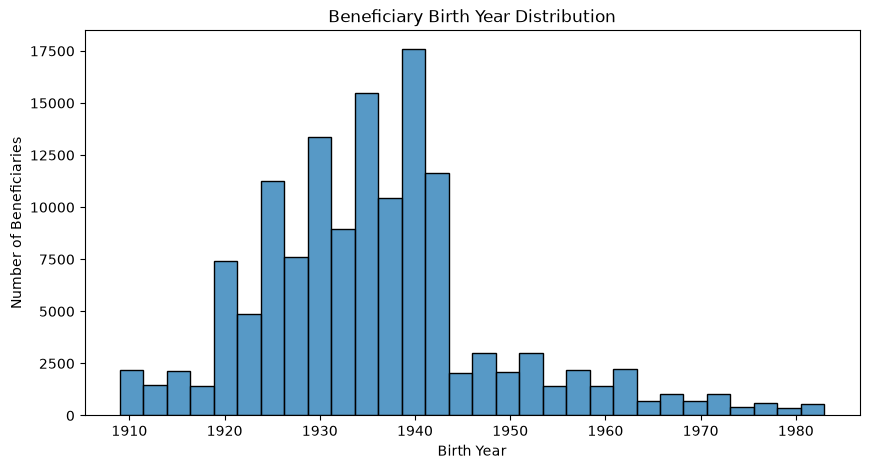

In [33]:
beneficiary_df["BirthYear"] = beneficiary_df["DOB"].dt.year

plt.figure(figsize=(10, 5))

sns.histplot(
    data=beneficiary_df,
    x="BirthYear",
    bins=30
)

plt.title("Beneficiary Birth Year Distribution")
plt.xlabel("Birth Year")
plt.ylabel("Number of Beneficiaries")

plt.show()

In [34]:
chronic_cols = [
    col for col in beneficiary_df.columns
    if "ChronicCond" in col
]

chronic_cols

['ChronicCond_Alzheimer',
 'ChronicCond_Heartfailure',
 'ChronicCond_KidneyDisease',
 'ChronicCond_Cancer',
 'ChronicCond_ObstrPulmonary',
 'ChronicCond_Depression',
 'ChronicCond_Diabetes',
 'ChronicCond_IschemicHeart',
 'ChronicCond_Osteoporasis',
 'ChronicCond_rheumatoidarthritis',
 'ChronicCond_stroke']

In [35]:
chronic_counts = {}

for col in chronic_cols:
    chronic_counts[col] = (beneficiary_df[col] == 1).sum()

chronic_counts = pd.Series(chronic_counts).sort_values(
    ascending=False
)

chronic_counts

ChronicCond_IschemicHeart          93644
ChronicCond_Diabetes               83391
ChronicCond_Heartfailure           68402
ChronicCond_Depression             49260
ChronicCond_Alzheimer              46026
ChronicCond_KidneyDisease          43279
ChronicCond_Osteoporasis           38059
ChronicCond_rheumatoidarthritis    35584
ChronicCond_ObstrPulmonary         32859
ChronicCond_Cancer                 16621
ChronicCond_stroke                 10954
dtype: int64

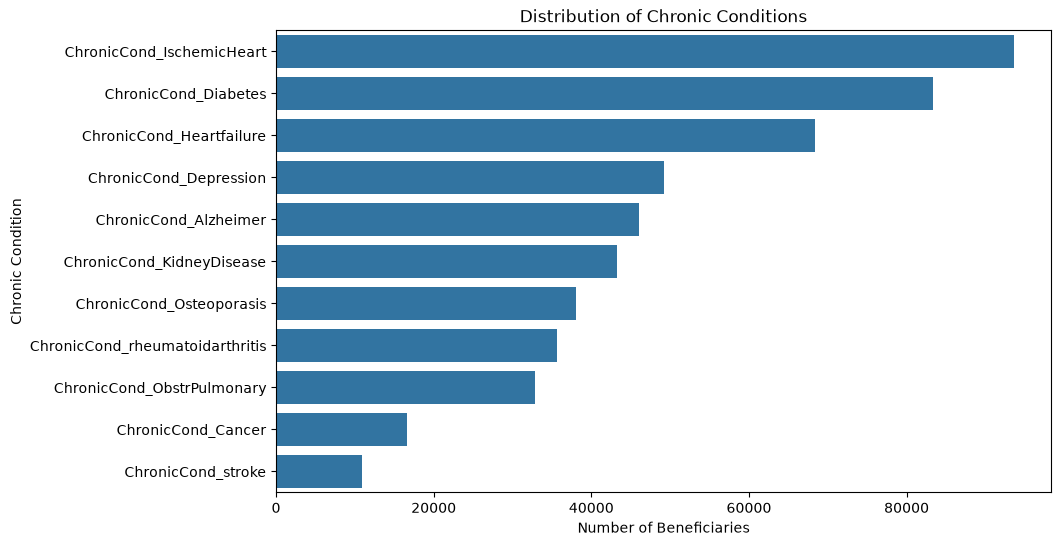

In [36]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=chronic_counts.values,
    y=chronic_counts.index
)

plt.title("Distribution of Chronic Conditions")
plt.xlabel("Number of Beneficiaries")
plt.ylabel("Chronic Condition")

plt.show()

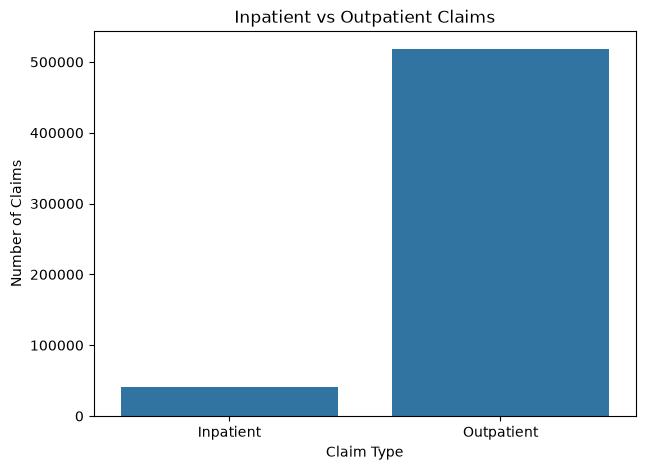

In [37]:
claim_counts = pd.Series({
    "Inpatient": len(inpatient_df),
    "Outpatient": len(outpatient_df)
})

plt.figure(figsize=(7, 5))

sns.barplot(
    x=claim_counts.index,
    y=claim_counts.values
)

plt.title("Inpatient vs Outpatient Claims")
plt.xlabel("Claim Type")
plt.ylabel("Number of Claims")

plt.show()

In [38]:
inpatient_df["InscClaimAmtReimbursed"].describe()

count     40474.000000
mean      10087.884074
std       10303.099402
min           0.000000
25%        4000.000000
50%        7000.000000
75%       12000.000000
max      125000.000000
Name: InscClaimAmtReimbursed, dtype: float64

In [39]:
outpatient_df["InscClaimAmtReimbursed"].describe()

count    517737.000000
mean        286.334799
std         694.034343
min           0.000000
25%          40.000000
50%          80.000000
75%         200.000000
max      102500.000000
Name: InscClaimAmtReimbursed, dtype: float64

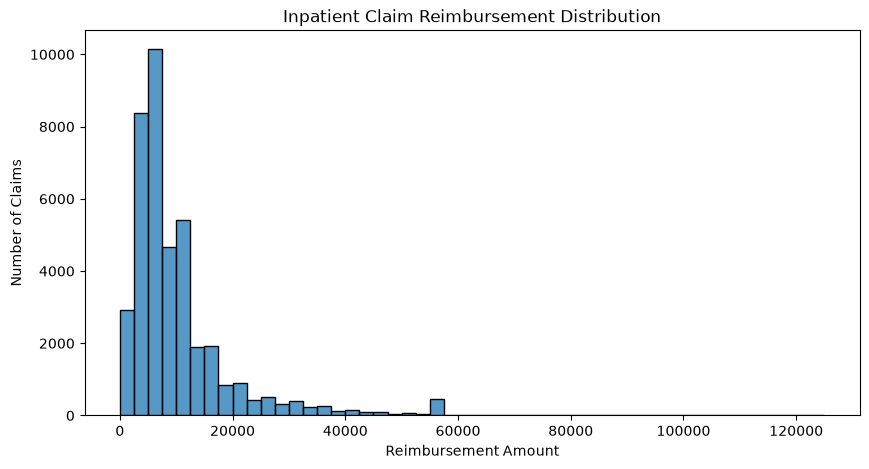

In [40]:
plt.figure(figsize=(10, 5))

sns.histplot(
    inpatient_df["InscClaimAmtReimbursed"],
    bins=50
)

plt.title("Inpatient Claim Reimbursement Distribution")
plt.xlabel("Reimbursement Amount")
plt.ylabel("Number of Claims")

plt.show()

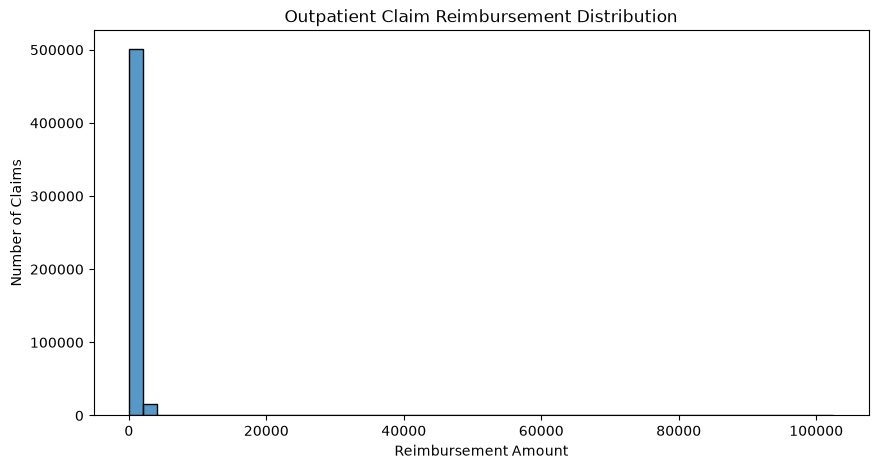

In [41]:
plt.figure(figsize=(10, 5))

sns.histplot(
    outpatient_df["InscClaimAmtReimbursed"],
    bins=50
)

plt.title("Outpatient Claim Reimbursement Distribution")
plt.xlabel("Reimbursement Amount")
plt.ylabel("Number of Claims")

plt.show()

In [42]:
inpatient_df["AdmissionDt"] = pd.to_datetime(
    inpatient_df["AdmissionDt"]
)

inpatient_df["DischargeDt"] = pd.to_datetime(
    inpatient_df["DischargeDt"]
)

In [43]:
inpatient_df["HospitalStayDays"] = (
    inpatient_df["DischargeDt"] -
    inpatient_df["AdmissionDt"]
).dt.days

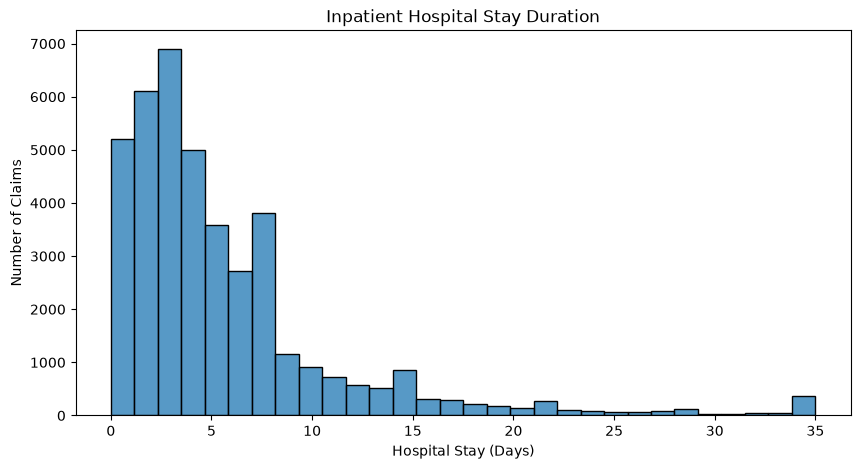

In [44]:
plt.figure(figsize=(10, 5))

sns.histplot(
    inpatient_df["HospitalStayDays"].dropna(),
    bins=30
)

plt.title("Inpatient Hospital Stay Duration")
plt.xlabel("Hospital Stay (Days)")
plt.ylabel("Number of Claims")

plt.show()

In [45]:
inpatient_provider_counts = (
    inpatient_df.groupby("Provider").size()
)

outpatient_provider_counts = (
    outpatient_df.groupby("Provider").size()
)

In [46]:
provider_claims = pd.DataFrame({
    "InpatientClaims": inpatient_provider_counts,
    "OutpatientClaims": outpatient_provider_counts
}).fillna(0)

provider_claims["TotalClaims"] = (
    provider_claims["InpatientClaims"] +
    provider_claims["OutpatientClaims"]
)

provider_claims.head()

,InpatientClaims,OutpatientClaims,TotalClaims
Provider,,,
PRV51001,5.0,20.0,25.0
PRV51003,62.0,70.0,132.0
PRV51004,0.0,149.0,149.0
PRV51005,0.0,1165.0,1165.0
PRV51007,3.0,69.0,72.0


In [47]:
provider_claims["TotalClaims"].describe()

count    5410.000000
mean      103.181331
std       272.456989
min         1.000000
25%        10.000000
50%        31.000000
75%        87.000000
max      8240.000000
Name: TotalClaims, dtype: float64

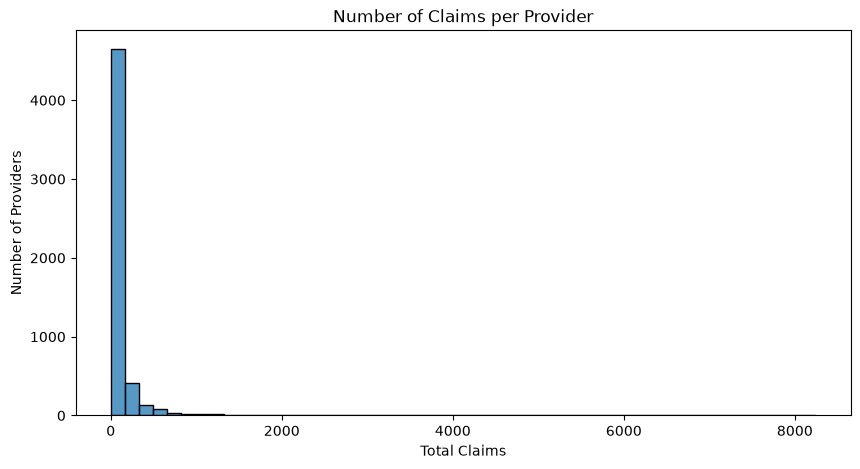

In [48]:
plt.figure(figsize=(10, 5))

sns.histplot(
    provider_claims["TotalClaims"],
    bins=50
)

plt.title("Number of Claims per Provider")
plt.xlabel("Total Claims")
plt.ylabel("Number of Providers")

plt.show()

In [49]:
inpatient_amount = (
    inpatient_df.groupby("Provider")[
        "InscClaimAmtReimbursed"
    ].sum()
)

outpatient_amount = (
    outpatient_df.groupby("Provider")[
        "InscClaimAmtReimbursed"
    ].sum()
)

In [50]:
provider_amount = pd.DataFrame({
    "InpatientReimbursement": inpatient_amount,
    "OutpatientReimbursement": outpatient_amount
}).fillna(0)

provider_amount["TotalReimbursement"] = (
    provider_amount["InpatientReimbursement"] +
    provider_amount["OutpatientReimbursement"]
)

provider_amount.head()

,InpatientReimbursement,OutpatientReimbursement,TotalReimbursement
Provider,,,
PRV51001,97000.0,7640.0,104640.0
PRV51003,573000.0,32670.0,605670.0
PRV51004,0.0,52170.0,52170.0
PRV51005,0.0,280910.0,280910.0
PRV51007,19000.0,14710.0,33710.0


In [51]:
provider_amount["TotalReimbursement"].describe()

count    5.410000e+03
mean     1.028730e+05
std      2.687367e+05
min      0.000000e+00
25%      4.460000e+03
50%      1.980500e+04
75%      8.556500e+04
max      5.996050e+06
Name: TotalReimbursement, dtype: float64

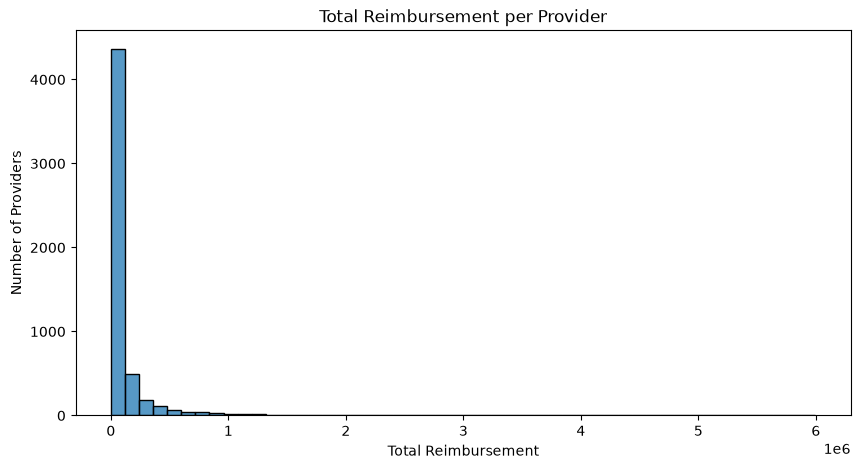

In [52]:
plt.figure(figsize=(10, 5))

sns.histplot(
    provider_amount["TotalReimbursement"],
    bins=50
)

plt.title("Total Reimbursement per Provider")
plt.xlabel("Total Reimbursement")
plt.ylabel("Number of Providers")

plt.show()

In [53]:
provider_analysis = provider_df.merge(
    provider_claims,
    on="Provider",
    how="left"
)

provider_analysis.head()

,Provider,PotentialFraud,InpatientClaims,OutpatientClaims,TotalClaims
0,PRV51001,No,5.0,20.0,25.0
1,PRV51003,Yes,62.0,70.0,132.0
2,PRV51004,No,0.0,149.0,149.0
3,PRV51005,Yes,0.0,1165.0,1165.0
4,PRV51007,No,3.0,69.0,72.0


In [54]:
provider_analysis[
    ["InpatientClaims", "OutpatientClaims", "TotalClaims"]
] = provider_analysis[
    ["InpatientClaims", "OutpatientClaims", "TotalClaims"]
].fillna(0)

In [55]:
provider_analysis.groupby(
    "PotentialFraud"
)[
    ["InpatientClaims", "OutpatientClaims", "TotalClaims"]
].mean()

,InpatientClaims,OutpatientClaims,TotalClaims
PotentialFraud,,,
No,3.481240,66.954119,70.435359
Yes,46.249012,374.296443,420.545455


In [56]:
provider_analysis = provider_analysis.merge(
    provider_amount[["TotalReimbursement"]],
    on="Provider",
    how="left"
)

provider_analysis["TotalReimbursement"] = (
    provider_analysis["TotalReimbursement"]
    .fillna(0)
)

In [57]:
provider_analysis.groupby(
    "PotentialFraud"
)["TotalReimbursement"].mean()

PotentialFraud
No      53193.723491
Yes    584350.039526
Name: TotalReimbursement, dtype: float64

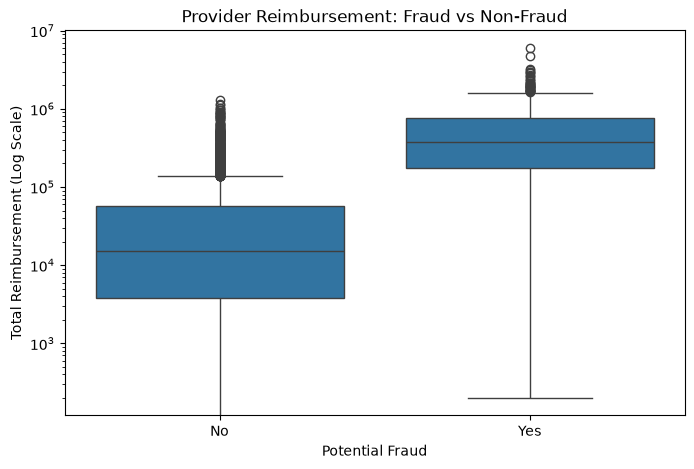

In [58]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=provider_analysis,
    x="PotentialFraud",
    y="TotalReimbursement"
)

plt.yscale("log")

plt.title(
    "Provider Reimbursement: Fraud vs Non-Fraud"
)

plt.xlabel("Potential Fraud")
plt.ylabel("Total Reimbursement (Log Scale)")

plt.show()

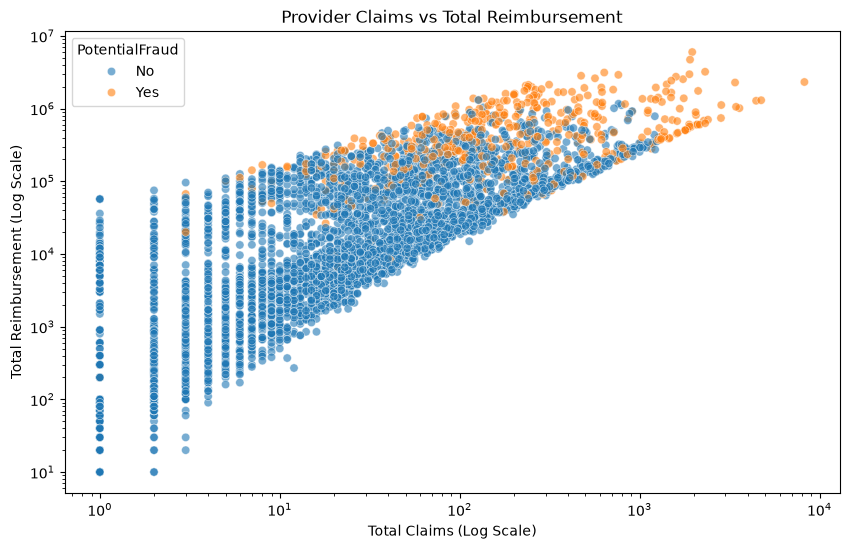

In [59]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=provider_analysis,
    x="TotalClaims",
    y="TotalReimbursement",
    hue="PotentialFraud",
    alpha=0.6
)

plt.xscale("log")
plt.yscale("log")

plt.title(
    "Provider Claims vs Total Reimbursement"
)

plt.xlabel("Total Claims (Log Scale)")
plt.ylabel("Total Reimbursement (Log Scale)")

plt.show()

# FEATURE ENGINEERING


In [60]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [61]:
from src.components.feature_engineering import (
    build_provider_features
)

ImportError: cannot import name 'build_provider_features' from 'src.components.feature_engineering' (c:\Users\suriy\Desktop\Healthcare-Insurance-claim-fraud-detection\src\components\feature_engineering.py)

In [ ]:
provider_features = build_provider_features(
    beneficiary_df=beneficiary_df,
    inpatient_df=inpatient_df,
    outpatient_df=outpatient_df,
    provider_df=provider_df,
)

In [ ]:
from pathlib import Path

processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
processed_file = processed_dir / "provider_features.csv"

provider_features.to_csv(
    processed_file,
    index=False
)

print(f"Saved provider features to: {processed_file}")

Saved provider features to: ..\data\processed\provider_features.csv


In [ ]:
print("Shape:", provider_features.shape)

Shape: (5410, 69)


In [ ]:
print(processed_file.exists())

True


In [ ]:
provider_features.shape

(5410, 69)

In [ ]:
provider_features.head()

,Provider,PotentialFraud,InpatientClaims,InpatientReimbursement,InpatientAverageClaim,InpatientMaximumClaim,AverageHospitalStay,MaximumHospitalStay,AverageInpatientClaimDuration,MaximumInpatientClaimDuration,...,MaximumBeneficiaryClaims,BeneficiaryConcentration,UniqueAttendingPhysicians,UniqueOperatingPhysicians,UniqueOtherPhysicians,ClaimsPerAttendingPhysician,UniqueDiagnosisCount,UniqueProcedureCount,DiagnosesPerClaim,ProceduresPerClaim
0,PRV51001,No,5.0,97000.0,19400.000000,42000.0,5.000000,14.0,5.000000,14.0,...,2,0.080000,14,5,8,1.785714,72.0,3.0,3.200000,0.120000
1,PRV51003,Yes,62.0,573000.0,9241.935484,57000.0,5.161290,27.0,5.161290,27.0,...,3,0.022727,44,7,22,3.000000,365.0,39.0,5.250000,0.363636
2,PRV51004,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4,0.026846,38,19,26,3.921053,267.0,NaN,2.583893,0.000000
3,PRV51005,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,21,0.018026,6,6,4,194.166667,1294.0,NaN,2.588841,0.000000
4,PRV51007,No,3.0,19000.0,6333.333333,10000.0,5.333333,7.0,5.333333,7.0,...,3,0.041667,10,5,7,7.200000,165.0,1.0,2.986111,0.013889


In [ ]:
print("Shape:", provider_features.shape)
print(
    "Unique providers:",
    provider_features["Provider"].nunique()
)

Shape: (5410, 69)
Unique providers: 5410


In [ ]:
print(provider_features.columns.tolist())

['Provider', 'PotentialFraud', 'InpatientClaims', 'InpatientReimbursement', 'InpatientAverageClaim', 'InpatientMaximumClaim', 'AverageHospitalStay', 'MaximumHospitalStay', 'AverageInpatientClaimDuration', 'MaximumInpatientClaimDuration', 'AverageInpatientDeductible', 'LongHospitalStayCount', 'LongHospitalStayRatio', 'HighValueInpatientClaimRatio', 'LongClaimDurationRatio', 'OutpatientClaims', 'OutpatientReimbursement', 'OutpatientAverageClaim', 'OutpatientMaximumClaim', 'AverageOutpatientClaimDuration', 'MaximumOutpatientClaimDuration', 'AverageOutpatientDeductible', 'HighValueOutpatientClaimRatio', 'LongOutpatientClaimDurationRatio', 'TotalClaims', 'TotalReimbursement', 'TotalDeductiblePaid', 'AverageClaimDuration', 'MaximumClaimDuration', 'AverageDeductiblePaid', 'MedianClaimAmount', 'ClaimAmountStd', 'MaximumClaimAmount', 'HighValueClaimCount', 'HighValueClaimRatio', 'InpatientClaimRatio', 'OutpatientClaimRatio', 'TotalAverageClaim', 'UniqueBeneficiaries', 'AverageChronicConditions'

In [ ]:
print(provider_features.dtypes)


Provider                           str
PotentialFraud                     str
InpatientClaims                float64
InpatientReimbursement         float64
InpatientAverageClaim          float64
                                ...   
ClaimsPerAttendingPhysician    float64
UniqueDiagnosisCount           float64
UniqueProcedureCount           float64
DiagnosesPerClaim              float64
ProceduresPerClaim             float64
Length: 69, dtype: object


In [ ]:
print(provider_features.isnull().sum())

Provider                          0
PotentialFraud                    0
InpatientClaims                3318
InpatientReimbursement         3318
InpatientAverageClaim          3318
                               ... 
ClaimsPerAttendingPhysician       0
UniqueDiagnosisCount              5
UniqueProcedureCount           3386
DiagnosesPerClaim                 0
ProceduresPerClaim                0
Length: 69, dtype: int64


# DATA TRANSFORMATION

In [ ]:
from src.components.data_transformation import DataTransformation

In [ ]:
data_transformer = DataTransformation(
    test_size=0.20,
    random_state=42
)

In [ ]:
X_train, X_test, y_train, y_test = data_transformer.transform(
    provider_features=provider_features
)

In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4328, 67)
X_test shape: (1082, 67)
y_train shape: (4328,)
y_test shape: (1082,)


In [ ]:
print("Training distribution:")
print(y_train.value_counts())

print("\nTesting distribution:")
print(y_test.value_counts())


Training distribution:
PotentialFraud
0    3923
1     405
Name: count, dtype: int64

Testing distribution:
PotentialFraud
0    981
1    101
Name: count, dtype: int64


In [ ]:
print(provider_features.columns.tolist())
print(provider_features.dtypes)

['Provider', 'PotentialFraud', 'InpatientClaims', 'InpatientReimbursement', 'InpatientAverageClaim', 'InpatientMaximumClaim', 'AverageHospitalStay', 'MaximumHospitalStay', 'AverageInpatientClaimDuration', 'MaximumInpatientClaimDuration', 'AverageInpatientDeductible', 'LongHospitalStayCount', 'LongHospitalStayRatio', 'HighValueInpatientClaimRatio', 'LongClaimDurationRatio', 'OutpatientClaims', 'OutpatientReimbursement', 'OutpatientAverageClaim', 'OutpatientMaximumClaim', 'AverageOutpatientClaimDuration', 'MaximumOutpatientClaimDuration', 'AverageOutpatientDeductible', 'HighValueOutpatientClaimRatio', 'LongOutpatientClaimDurationRatio', 'TotalClaims', 'TotalReimbursement', 'TotalDeductiblePaid', 'AverageClaimDuration', 'MaximumClaimDuration', 'AverageDeductiblePaid', 'MedianClaimAmount', 'ClaimAmountStd', 'MaximumClaimAmount', 'HighValueClaimCount', 'HighValueClaimRatio', 'InpatientClaimRatio', 'OutpatientClaimRatio', 'TotalAverageClaim', 'UniqueBeneficiaries', 'AverageChronicConditions'

In [ ]:
provider_features_v2 = build_provider_features(
    beneficiary_df=beneficiary_df,
    inpatient_df=inpatient_df,
    outpatient_df=outpatient_df,
    provider_df=provider_df
)

In [ ]:
print("Shape:", provider_features_v2.shape)
print(provider_features_v2.columns.tolist())

Shape: (5410, 69)
['Provider', 'PotentialFraud', 'InpatientClaims', 'InpatientReimbursement', 'InpatientAverageClaim', 'InpatientMaximumClaim', 'AverageHospitalStay', 'MaximumHospitalStay', 'AverageInpatientClaimDuration', 'MaximumInpatientClaimDuration', 'AverageInpatientDeductible', 'LongHospitalStayCount', 'LongHospitalStayRatio', 'HighValueInpatientClaimRatio', 'LongClaimDurationRatio', 'OutpatientClaims', 'OutpatientReimbursement', 'OutpatientAverageClaim', 'OutpatientMaximumClaim', 'AverageOutpatientClaimDuration', 'MaximumOutpatientClaimDuration', 'AverageOutpatientDeductible', 'HighValueOutpatientClaimRatio', 'LongOutpatientClaimDurationRatio', 'TotalClaims', 'TotalReimbursement', 'TotalDeductiblePaid', 'AverageClaimDuration', 'MaximumClaimDuration', 'AverageDeductiblePaid', 'MedianClaimAmount', 'ClaimAmountStd', 'MaximumClaimAmount', 'HighValueClaimCount', 'HighValueClaimRatio', 'InpatientClaimRatio', 'OutpatientClaimRatio', 'TotalAverageClaim', 'UniqueBeneficiaries', 'Average

In [ ]:
missing_values = (
    provider_features.isnull()
    .sum()
    .sort_values(ascending=False)
)

print(missing_values[missing_values > 0])

UniqueProcedureCount                3386
AverageInpatientDeductible          3327
InpatientReimbursement              3318
InpatientAverageClaim               3318
InpatientClaims                     3318
HighValueInpatientClaimRatio        3318
LongClaimDurationRatio              3318
MaximumHospitalStay                 3318
InpatientMaximumClaim               3318
AverageInpatientClaimDuration       3318
MaximumInpatientClaimDuration       3318
LongHospitalStayCount               3318
AverageHospitalStay                 3318
LongHospitalStayRatio               3318
HighValueOutpatientClaimRatio        398
AverageOutpatientDeductible          398
OutpatientClaims                     398
OutpatientAverageClaim               398
OutpatientMaximumClaim               398
AverageOutpatientClaimDuration       398
OutpatientReimbursement              398
LongOutpatientClaimDurationRatio     398
MaximumOutpatientClaimDuration       398
ClaimAmountStd                       240
UniqueDiagnosisC

In [ ]:
print(
    provider_features[
        "UniqueProcedureCount"
    ].describe()
)
print(
    provider_features[
        "UniqueDiagnosisCount"
    ].describe()
)
print(
    provider_features[
        "ClaimAmountStd"
    ].describe()
)

count    2024.000000
mean       11.801877
std        16.642286
min         1.000000
25%         2.000000
50%         6.000000
75%        13.000000
max       180.000000
Name: UniqueProcedureCount, dtype: float64
count    5405.000000
mean      174.997040
std       270.988261
min         1.000000
25%        30.000000
50%        84.000000
75%       202.000000
max      3859.000000
Name: UniqueDiagnosisCount, dtype: float64
count     5170.000000
mean      2536.575975
std       3694.559177
min          0.000000
25%        445.314551
50%        714.121955
75%       3610.717613
max      50204.581464
Name: ClaimAmountStd, dtype: float64


In [ ]:
from src.components.feature_engineering import (
    build_provider_features
)

In [ ]:
provider_features = build_provider_features(
    beneficiary_df=beneficiary_df,
    inpatient_df=inpatient_df,
    outpatient_df=outpatient_df,
    provider_df=provider_df,
)

In [ ]:
print("Shape:", provider_features.shape)

print(
    provider_features.columns.tolist()
)

Shape: (5410, 69)
['Provider', 'PotentialFraud', 'InpatientClaims', 'InpatientReimbursement', 'InpatientAverageClaim', 'InpatientMaximumClaim', 'AverageHospitalStay', 'MaximumHospitalStay', 'AverageInpatientClaimDuration', 'MaximumInpatientClaimDuration', 'AverageInpatientDeductible', 'LongHospitalStayCount', 'LongHospitalStayRatio', 'HighValueInpatientClaimRatio', 'LongClaimDurationRatio', 'OutpatientClaims', 'OutpatientReimbursement', 'OutpatientAverageClaim', 'OutpatientMaximumClaim', 'AverageOutpatientClaimDuration', 'MaximumOutpatientClaimDuration', 'AverageOutpatientDeductible', 'HighValueOutpatientClaimRatio', 'LongOutpatientClaimDurationRatio', 'TotalClaims', 'TotalReimbursement', 'TotalDeductiblePaid', 'AverageClaimDuration', 'MaximumClaimDuration', 'AverageDeductiblePaid', 'MedianClaimAmount', 'ClaimAmountStd', 'MaximumClaimAmount', 'HighValueClaimCount', 'HighValueClaimRatio', 'InpatientClaimRatio', 'OutpatientClaimRatio', 'TotalAverageClaim', 'UniqueBeneficiaries', 'Average

In [ ]:
print(
    provider_features.columns[
        provider_features.columns.duplicated()
    ].tolist()
)

[]


In [ ]:
print(
    provider_features.dtypes.value_counts()
)

float64    55
int64      12
str         2
Name: count, dtype: int64


In [ ]:
missing_values = (
    provider_features.isnull()
    .sum()
    .sort_values(ascending=False)
)

print(
    missing_values[
        missing_values > 0
    ]
)

UniqueProcedureCount                3386
AverageInpatientDeductible          3327
InpatientReimbursement              3318
InpatientAverageClaim               3318
InpatientClaims                     3318
HighValueInpatientClaimRatio        3318
LongClaimDurationRatio              3318
MaximumHospitalStay                 3318
InpatientMaximumClaim               3318
AverageInpatientClaimDuration       3318
MaximumInpatientClaimDuration       3318
LongHospitalStayCount               3318
AverageHospitalStay                 3318
LongHospitalStayRatio               3318
HighValueOutpatientClaimRatio        398
AverageOutpatientDeductible          398
OutpatientClaims                     398
OutpatientAverageClaim               398
OutpatientMaximumClaim               398
AverageOutpatientClaimDuration       398
OutpatientReimbursement              398
LongOutpatientClaimDurationRatio     398
MaximumOutpatientClaimDuration       398
ClaimAmountStd                       240
UniqueDiagnosisC

In [ ]:
from pathlib import Path

processed_dir = Path("../data/processed")
processed_dir.mkdir(
    parents=True,
    exist_ok=True
)

provider_features.to_csv(
    processed_dir / "provider_features.csv",
    index=False
)

print(
    "Saved:",
    processed_dir / "provider_features.csv"
)

Saved: ..\data\processed\provider_features.csv


In [ ]:
provider_features.to_csv(
    "../data/processed/provider_features.csv",
    index=False
)

print("Updated provider_features.csv saved successfully.")

Updated provider_features.csv saved successfully.


In [ ]:
from src.components.feature_engineering import FeatureEngineering

feature_engineer = FeatureEngineering()

provider_features = feature_engineer.build_provider_features(
    provider_df=provider_df,
    beneficiary_df=beneficiary_df,
    inpatient_df=inpatient_df,
    outpatient_df=outpatient_df,
)

print("Shape:", provider_features.shape)
print(provider_features.columns.tolist())

Shape: (5410, 73)
['Provider', 'PotentialFraud', 'InpatientClaims', 'InpatientReimbursement', 'InpatientAverageClaim', 'InpatientMaximumClaim', 'AverageHospitalStay', 'MaximumHospitalStay', 'AverageInpatientClaimDuration', 'MaximumInpatientClaimDuration', 'AverageInpatientDeductible', 'LongHospitalStayCount', 'LongHospitalStayRatio', 'HighValueInpatientClaimRatio', 'LongClaimDurationRatio', 'OutpatientClaims', 'OutpatientReimbursement', 'OutpatientAverageClaim', 'OutpatientMaximumClaim', 'AverageOutpatientClaimDuration', 'MaximumOutpatientClaimDuration', 'AverageOutpatientDeductible', 'HighValueOutpatientClaimRatio', 'LongOutpatientClaimDurationRatio', 'TotalClaims', 'TotalReimbursement', 'TotalDeductiblePaid', 'InpatientClaimRatio', 'OutpatientClaimRatio', 'TotalAverageClaim', 'UniqueBeneficiaries', 'MaximumBeneficiaryClaims', 'ClaimsPerBeneficiary', 'BeneficiaryConcentration', 'AverageChronicConditions', 'MaximumChronicConditions', 'AverageGender', 'AveragePartACoverageMonths', 'Aver

In [ ]:
from src.components.feature_engineering import FeatureEngineering

feature_engineer = FeatureEngineering()

provider_features = feature_engineer.build_provider_features(
    provider_df=provider_df,
    beneficiary_df=beneficiary_df,
    inpatient_df=inpatient_df,
    outpatient_df=outpatient_df,
)

print("Shape:", provider_features.shape)
print(provider_features.columns.tolist())

Shape: (5410, 73)
['Provider', 'PotentialFraud', 'InpatientClaims', 'InpatientReimbursement', 'InpatientAverageClaim', 'InpatientMaximumClaim', 'AverageHospitalStay', 'MaximumHospitalStay', 'AverageInpatientClaimDuration', 'MaximumInpatientClaimDuration', 'AverageInpatientDeductible', 'LongHospitalStayCount', 'LongHospitalStayRatio', 'HighValueInpatientClaimRatio', 'LongClaimDurationRatio', 'OutpatientClaims', 'OutpatientReimbursement', 'OutpatientAverageClaim', 'OutpatientMaximumClaim', 'AverageOutpatientClaimDuration', 'MaximumOutpatientClaimDuration', 'AverageOutpatientDeductible', 'HighValueOutpatientClaimRatio', 'LongOutpatientClaimDurationRatio', 'TotalClaims', 'TotalReimbursement', 'TotalDeductiblePaid', 'InpatientClaimRatio', 'OutpatientClaimRatio', 'TotalAverageClaim', 'UniqueBeneficiaries', 'MaximumBeneficiaryClaims', 'ClaimsPerBeneficiary', 'BeneficiaryConcentration', 'AverageChronicConditions', 'MaximumChronicConditions', 'AverageGender', 'AveragePartACoverageMonths', 'Aver

In [ ]:
# Check the final feature dataset

print("Shape:", provider_features.shape)

print("\nTarget distribution:")
print(provider_features["PotentialFraud"].value_counts())

print("\nMissing values:")
missing_values = (
    provider_features.isnull()
    .sum()
    .sort_values(ascending=False)
)

print(
    missing_values[
        missing_values > 0
    ]
)

print("\nConstant columns:")

constant_columns = [
    column
    for column in provider_features.columns
    if provider_features[column].nunique(dropna=False) <= 1
]

print(constant_columns)

print("\nDuplicate columns:")

duplicate_columns = (
    provider_features
    .T
    .duplicated()
)

print(
    provider_features.columns[
        duplicate_columns
    ].tolist()
)

Shape: (5410, 73)

Target distribution:
PotentialFraud
No     4904
Yes     506
Name: count, dtype: int64

Missing values:
ProceduresPerClaim                  3386
UniqueProcedureCount                3386
AverageInpatientDeductible          3327
MaximumHospitalStay                 3318
InpatientMaximumClaim               3318
AverageInpatientClaimDuration       3318
InpatientReimbursement              3318
AverageHospitalStay                 3318
InpatientAverageClaim               3318
HighValueInpatientClaimRatio        3318
LongClaimDurationRatio              3318
LongHospitalStayCount               3318
MaximumInpatientClaimDuration       3318
LongHospitalStayRatio               3318
ClaimsPerOperatingPhysician          557
ClaimsPerOtherPhysician              532
AverageOutpatientClaimDuration       398
LongOutpatientClaimDurationRatio     398
HighValueOutpatientClaimRatio        398
OutpatientReimbursement              398
MaximumOutpatientClaimDuration       398
AverageOutpatient

In [ ]:
from src.components.data_transformation import DataTransformation

data_transformer = DataTransformation()

X_train, X_test, y_train, y_test = (
    data_transformer.transform(
        provider_features=provider_features
    )
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:")
print(y_train.value_counts())

print("\ny_test:")
print(y_test.value_counts())

X_train: (4328, 71)
X_test: (1082, 71)
y_train:
PotentialFraud
0    3923
1     405
Name: count, dtype: int64

y_test:
PotentialFraud
0    981
1    101
Name: count, dtype: int64


In [ ]:
import os

processed_dir = os.path.abspath(
    os.path.join(
        os.getcwd(),
        "..",
        "data",
        "processed"
    )
)

os.makedirs(
    processed_dir,
    exist_ok=True
)

output_path = os.path.join(
    processed_dir,
    "provider_features.csv"
)

provider_features.to_csv(
    output_path,
    index=False
)

print("Saved successfully to:")
print(output_path)

print("Shape:", provider_features.shape)

Saved successfully to:
c:\Users\suriy\Desktop\Healthcare-Insurance-claim-fraud-detection\data\processed\provider_features.csv
Shape: (5410, 73)


In [ ]:
from src.components.feature_engineering import FeatureEngineering

feature_engineer = FeatureEngineering()

provider_features = feature_engineer.build_provider_features(
    provider_df=provider_df,
    beneficiary_df=beneficiary_df,
    inpatient_df=inpatient_df,
    outpatient_df=outpatient_df
)

print("Shape:", provider_features.shape)
print("\nColumns:")
print(provider_features.columns.tolist())

Shape: (5410, 81)

Columns:
['Provider', 'PotentialFraud', 'InpatientClaims', 'InpatientReimbursement', 'InpatientAverageClaim', 'InpatientMaximumClaim', 'AverageHospitalStay', 'MaximumHospitalStay', 'AverageInpatientClaimDuration', 'MaximumInpatientClaimDuration', 'AverageInpatientDeductible', 'LongHospitalStayCount', 'LongHospitalStayRatio', 'HighValueInpatientClaimRatio', 'LongClaimDurationRatio', 'OutpatientClaims', 'OutpatientReimbursement', 'OutpatientAverageClaim', 'OutpatientMaximumClaim', 'AverageOutpatientClaimDuration', 'MaximumOutpatientClaimDuration', 'AverageOutpatientDeductible', 'HighValueOutpatientClaimRatio', 'LongOutpatientClaimDurationRatio', 'TotalClaims', 'TotalReimbursement', 'TotalDeductiblePaid', 'InpatientClaimRatio', 'OutpatientClaimRatio', 'TotalAverageClaim', 'HasInpatientActivity', 'HasOutpatientActivity', 'InpatientReimbursementRatio', 'OutpatientReimbursementRatio', 'UniqueBeneficiaries', 'MaximumBeneficiaryClaims', 'ClaimsPerBeneficiary', 'BeneficiaryCo

In [ ]:
import os

processed_path = os.path.join(
    PROJECT_ROOT,
    "data",
    "processed",
    "provider_features.csv"
)

os.makedirs(
    os.path.dirname(processed_path),
    exist_ok=True
)

provider_features.to_csv(
    processed_path,
    index=False
)

print("Saved successfully to:")
print(processed_path)
print("Shape:", provider_features.shape)

Saved successfully to:
c:\Users\suriy\Desktop\Healthcare-Insurance-claim-fraud-detection\data\processed\provider_features.csv
Shape: (5410, 81)


In [ ]:
print("=" * 80)
print("UPDATED FEATURE DATASET CHECK")
print("=" * 80)

print("Shape:", provider_features.shape)

print("\nTarget:")
print(provider_features["PotentialFraud"].value_counts())

print("\nDuplicate columns:")
print(
    provider_features.columns[
        provider_features.columns.duplicated()
    ].tolist()
)

print("\nDuplicate rows:")
print(provider_features.duplicated().sum())

print("\nMissing values:")
missing = provider_features.isnull().sum()
print(missing[missing > 0])

print("\nNew feature check:")

new_features = [
    "HasInpatientActivity",
    "HasOutpatientActivity",
    "InpatientReimbursementRatio",
    "OutpatientReimbursementRatio",
    "ReimbursementPerBeneficiary",
    "DeductiblePerBeneficiary",
    "DurationVariationRatio",
    "ClaimAmountCV"
]

for feature in new_features:
    print(
        f"{feature}:",
        feature in provider_features.columns
    )

UPDATED FEATURE DATASET CHECK
Shape: (5410, 81)

Target:
PotentialFraud
No     4904
Yes     506
Name: count, dtype: int64

Duplicate columns:
[]

Duplicate rows:
0

Missing values:
InpatientReimbursement              3318
InpatientAverageClaim               3318
InpatientMaximumClaim               3318
AverageHospitalStay                 3318
MaximumHospitalStay                 3318
AverageInpatientClaimDuration       3318
MaximumInpatientClaimDuration       3318
AverageInpatientDeductible          3327
LongHospitalStayCount               3318
LongHospitalStayRatio               3318
HighValueInpatientClaimRatio        3318
LongClaimDurationRatio              3318
OutpatientReimbursement              398
OutpatientAverageClaim               398
OutpatientMaximumClaim               398
AverageOutpatientClaimDuration       398
MaximumOutpatientClaimDuration       398
AverageOutpatientDeductible          398
HighValueOutpatientClaimRatio        398
LongOutpatientClaimDurationRatio     398

In [ ]:
import os
import pandas as pd

processed_path = os.path.join(
    PROJECT_ROOT,
    "data",
    "processed",
    "provider_features.csv"
)

provider_features = pd.read_csv(processed_path)

print("Shape:", provider_features.shape)

print("\nDuplicate columns:")
print(
    provider_features.columns[
        provider_features.columns.duplicated()
    ].tolist()
)

print("\nDuplicate rows:")
print(provider_features.duplicated().sum())

print("\nNew features:")

new_features = [
    "HasInpatientActivity",
    "HasOutpatientActivity",
    "InpatientReimbursementRatio",
    "ReimbursementPerBeneficiary",
    "DeductiblePerBeneficiary",
    "ClaimAmountCV",
    "LogClaimAmountCV"
]

for feature in new_features:
    print(
        f"{feature}:",
        feature in provider_features.columns
    )

Shape: (5410, 81)

Duplicate columns:
[]

Duplicate rows:
0

New features:
HasInpatientActivity: True
HasOutpatientActivity: True
InpatientReimbursementRatio: True
ReimbursementPerBeneficiary: True
DeductiblePerBeneficiary: True
ClaimAmountCV: True
LogClaimAmountCV: False


In [ ]:
from src.components.feature_engineering import FeatureEngineering

feature_engineer = FeatureEngineering()

provider_features = feature_engineer.build_provider_features(
    provider_df=provider_df,
    beneficiary_df=beneficiary_df,
    inpatient_df=inpatient_df,
    outpatient_df=outpatient_df
)

print("NEW FEATURE DATASET")
print("=" * 80)

print("Shape:", provider_features.shape)

print("\nColumns:")
print(provider_features.columns.tolist())

NEW FEATURE DATASET
Shape: (5410, 81)

Columns:
['Provider', 'PotentialFraud', 'InpatientClaims', 'InpatientReimbursement', 'InpatientAverageClaim', 'InpatientMaximumClaim', 'AverageHospitalStay', 'MaximumHospitalStay', 'AverageInpatientClaimDuration', 'MaximumInpatientClaimDuration', 'AverageInpatientDeductible', 'LongHospitalStayCount', 'LongHospitalStayRatio', 'HighValueInpatientClaimRatio', 'LongClaimDurationRatio', 'OutpatientClaims', 'OutpatientReimbursement', 'OutpatientAverageClaim', 'OutpatientMaximumClaim', 'AverageOutpatientClaimDuration', 'MaximumOutpatientClaimDuration', 'AverageOutpatientDeductible', 'HighValueOutpatientClaimRatio', 'LongOutpatientClaimDurationRatio', 'TotalClaims', 'TotalReimbursement', 'TotalDeductiblePaid', 'InpatientClaimRatio', 'OutpatientClaimRatio', 'TotalAverageClaim', 'HasInpatientActivity', 'HasOutpatientActivity', 'InpatientReimbursementRatio', 'OutpatientReimbursementRatio', 'UniqueBeneficiaries', 'MaximumBeneficiaryClaims', 'ClaimsPerBenefici

In [ ]:
print("\nRequired feature check:")

for feature in [
    "HasInpatientActivity",
    "HasOutpatientActivity",
    "InpatientReimbursementRatio",
    "ReimbursementPerBeneficiary",
    "DeductiblePerBeneficiary",
    "ClaimAmountCV",
    "LogClaimAmountCV"
]:
    print(
        feature,
        ":",
        feature in provider_features.columns
    )


Required feature check:
HasInpatientActivity : True
HasOutpatientActivity : True
InpatientReimbursementRatio : True
ReimbursementPerBeneficiary : True
DeductiblePerBeneficiary : True
ClaimAmountCV : True
LogClaimAmountCV : False


In [ ]:
from src.components.feature_engineering import FeatureEngineering

In [ ]:
feature_engineer = FeatureEngineering()

In [ ]:
provider_features = feature_engineer.build_provider_features(
    provider_df=provider_df,
    beneficiary_df=beneficiary_df,
    inpatient_df=inpatient_df,
    outpatient_df=outpatient_df
)

In [ ]:
print("Shape:", provider_features.shape)

for feature in [
    "HasInpatientActivity",
    "HasOutpatientActivity",
    "InpatientReimbursementRatio",
    "ReimbursementPerBeneficiary",
    "DeductiblePerBeneficiary",
    "ClaimAmountCV",
    "LogClaimAmountCV"
]:
    print(
        feature,
        ":",
        feature in provider_features.columns
    )

Shape: (5410, 81)
HasInpatientActivity : True
HasOutpatientActivity : True
InpatientReimbursementRatio : True
ReimbursementPerBeneficiary : True
DeductiblePerBeneficiary : True
ClaimAmountCV : True
LogClaimAmountCV : False


In [ ]:
import inspect
from src.components.feature_engineering import FeatureEngineering

print(
    inspect.getfile(FeatureEngineering)
)

c:\Users\suriy\Desktop\Healthcare-Insurance-claim-fraud-detection\src\components\feature_engineering.py


In [ ]:
import inspect
from src.components.feature_engineering import FeatureEngineering

print("Python is loading FeatureEngineering from:")
print(inspect.getfile(FeatureEngineering))

print("\nDoes the loaded source contain LogClaimAmountCV?")

source = inspect.getsource(FeatureEngineering)

print("LogClaimAmountCV" in source)

Python is loading FeatureEngineering from:
c:\Users\suriy\Desktop\Healthcare-Insurance-claim-fraud-detection\src\components\feature_engineering.py

Does the loaded source contain LogClaimAmountCV?
False


In [ ]:
import inspect
from src.components.feature_engineering import FeatureEngineering

print(inspect.getfile(FeatureEngineering))

source = inspect.getsource(FeatureEngineering)

print(
    "LogClaimAmountCV" in source
)

c:\Users\suriy\Desktop\Healthcare-Insurance-claim-fraud-detection\src\components\feature_engineering.py
False


In [ ]:
from src.components.feature_engineering import FeatureEngineering

feature_engineer = FeatureEngineering()

provider_features = feature_engineer.build_provider_features(
    provider_df=provider_df,
    beneficiary_df=beneficiary_df,
    inpatient_df=inpatient_df,
    outpatient_df=outpatient_df
)

In [ ]:
print("Shape:", provider_features.shape)

for feature in [
    "HasInpatientActivity",
    "HasOutpatientActivity",
    "InpatientReimbursementRatio",
    "ReimbursementPerBeneficiary",
    "DeductiblePerBeneficiary",
    "ClaimAmountCV",
    "LogClaimAmountCV"
]:
    print(
        feature,
        ":",
        feature in provider_features.columns
    )

Shape: (5410, 81)
HasInpatientActivity : True
HasOutpatientActivity : True
InpatientReimbursementRatio : True
ReimbursementPerBeneficiary : True
DeductiblePerBeneficiary : True
ClaimAmountCV : True
LogClaimAmountCV : False


In [62]:
import inspect
from src.components.feature_engineering import FeatureEngineering

print(inspect.getfile(FeatureEngineering))

source = inspect.getsource(FeatureEngineering)

print(
    "LogClaimAmountCV:",
    "LogClaimAmountCV" in source
)

print(
    "DurationVariationRatio:",
    "DurationVariationRatio" in source
)

print(
    "OutpatientReimbursementRatio:",
    "OutpatientReimbursementRatio" in source
)

c:\Users\suriy\Desktop\Healthcare-Insurance-claim-fraud-detection\src\components\feature_engineering.py
LogClaimAmountCV: True
DurationVariationRatio: True
OutpatientReimbursementRatio: True


In [63]:
feature_engineer = FeatureEngineering()

provider_features = feature_engineer.build_provider_features(
    provider_df=provider_df,
    beneficiary_df=beneficiary_df,
    inpatient_df=inpatient_df,
    outpatient_df=outpatient_df
)

In [64]:
print("Shape:", provider_features.shape)

print("\nNew feature:")
print(
    "LogClaimAmountCV" in provider_features.columns
)

print("\nRemoved features:")
print(
    "DurationVariationRatio" in provider_features.columns
)
print(
    "OutpatientReimbursementRatio" in provider_features.columns
)

print("\nDuplicate columns:")
print(
    provider_features.columns.duplicated().sum()
)

Shape: (5410, 123)

New feature:
True

Removed features:
False
False

Duplicate columns:
0


In [65]:
import os

processed_path = os.path.join(
    PROJECT_ROOT,
    "data",
    "processed",
    "provider_features.csv"
)

provider_features.to_csv(
    processed_path,
    index=False
)

print("=" * 80)
print("UPDATED PROVIDER FEATURES SAVED")
print("=" * 80)

print("Path:", processed_path)
print("Shape:", provider_features.shape)

UPDATED PROVIDER FEATURES SAVED
Path: c:\Users\suriy\Desktop\Healthcare-Insurance-claim-fraud-detection\data\processed\provider_features.csv
Shape: (5410, 123)


In [66]:
import pandas as pd

check_df = pd.read_csv(processed_path)

print("=" * 80)
print("SAVED FILE VERIFICATION")
print("=" * 80)

print("Shape:", check_df.shape)

print(
    "LogClaimAmountCV:",
    "LogClaimAmountCV" in check_df.columns
)

print(
    "OutpatientReimbursementRatio:",
    "OutpatientReimbursementRatio" in check_df.columns
)

print(
    "DurationVariationRatio:",
    "DurationVariationRatio" in check_df.columns
)

print(
    "Duplicate columns:",
    check_df.columns.duplicated().sum()
)

SAVED FILE VERIFICATION
Shape: (5410, 123)
LogClaimAmountCV: True
OutpatientReimbursementRatio: False
DurationVariationRatio: False
Duplicate columns: 0


In [67]:
print("Shape:", provider_features.shape)

print("Duplicate columns:",
      provider_features.columns.duplicated().sum())

print("Duplicate rows:",
      provider_features.duplicated().sum())

for feature in [
    "HasInpatientActivity",
    "HasOutpatientActivity",
    "ClaimAmountCV",
    "LogClaimAmountCV",
    "ClaimAmountIQR",
    "ClaimAmountOutlierRatio",
    "TopBeneficiaryClaimShare",
    "MonthlyClaimCV",
    "TotalReimbursementPercentile",
]:
    print(
        feature,
        ":",
        feature in provider_features.columns
    )

Shape: (5410, 123)
Duplicate columns: 0
Duplicate rows: 0
HasInpatientActivity : True
HasOutpatientActivity : True
ClaimAmountCV : True
LogClaimAmountCV : True
ClaimAmountIQR : True
ClaimAmountOutlierRatio : True
TopBeneficiaryClaimShare : True
MonthlyClaimCV : True
TotalReimbursementPercentile : True


In [68]:
import os

processed_dir = os.path.abspath(
    os.path.join(
        os.getcwd(),
        "..",
        "data",
        "processed"
    )
)

os.makedirs(processed_dir, exist_ok=True)

output_path = os.path.join(
    processed_dir,
    "provider_features.csv"
)

provider_features.to_csv(
    output_path,
    index=False
)

print("Saved successfully to:")
print(output_path)
print("Shape:", provider_features.shape)

Saved successfully to:
c:\Users\suriy\Desktop\Healthcare-Insurance-claim-fraud-detection\data\processed\provider_features.csv
Shape: (5410, 123)
